# VQC Based on IQC and IQC:AIL

## Imports

In [32]:
import qiskit
from qiskit_machine_learning.algorithms import VQC
from qiskit.circuit import QuantumCircuit,Parameter
from qiskit.compiler import transpile
from qiskit_aer import Aer
from qiskit.visualization import plot_histogram, visualize_transition, plot_bloch_vector
from qiskit.circuit.library import UnitaryGate,Initialize
from qiskit.quantum_info import Statevector,partial_trace, DensityMatrix

import pennylane as qml
from pennylane import numpy as pnp
import qutip

import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.model_selection import StratifiedKFold,train_test_split
from sklearn.datasets import make_blobs
from sklearn.multiclass import OneVsRestClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score

from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pdflatex

import pandas as pd


## Base de Dados

In [33]:
#Parâmetros
RANDOM_SEED = 42
N_SAMPLES = 300
N_FEATURES = 8
N_CENTERS = 5
N_PRINTINGS = N_SAMPLES//10
LEARNING_RATE = 0.01
RESPONSE_METHOD = "predict"
results = []

### IQC

In [19]:
#Gerando o dataset
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=N_CENTERS, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
    X = X - 1
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_blobs,y_blobs=generate_blobs(normalize_col=True)


### IQC:AIL

In [9]:
#Gerando o dataset
def generate_blobs(normalize_col=False, normalize_lin=False):
  X, y = make_blobs(n_samples=N_SAMPLES, n_features=N_FEATURES, centers=N_CENTERS, random_state=RANDOM_SEED,cluster_std=0.7)

  if normalize_col:
    scaler = MinMaxScaler()
    scaler.fit(X)
    X = scaler.transform(X)
  if normalize_lin:
    X = preprocessing.normalize(X,axis=1,norm='l2')


  return X, y

X_blobs,y_blobs=generate_blobs(normalize_col=True)

## Estratificando o dataset

In [22]:
#Gerando os datasets de treino e teste
X_train, X_test, y_train, y_test=train_test_split(X_blobs,y_blobs,test_size=0.3,train_size=0.7)

In [23]:
#Plotando os dados em que N_features==2
if N_FEATURES==2:
    plt.figure(figsize=(8, 8))
    plt.title("Exemplo simples de base de dados Moons", fontsize="small")
    plt.scatter(X_blobs[:, 0], X_blobs[:, 1], marker="o", s=25, c=y_blobs, edgecolor="k")
    plt.savefig("Dataset_blobs.png", dpi=1500)
    plt.show()

## Quantum Circuit

Não geraremos imagens ainda

### Circuito IQC em Pennylane

Ainda em construção

<QNode: device='<default.qubit device (wires=4) at 0x24a2cf1dc70>', interface='auto', diff_method='best'>


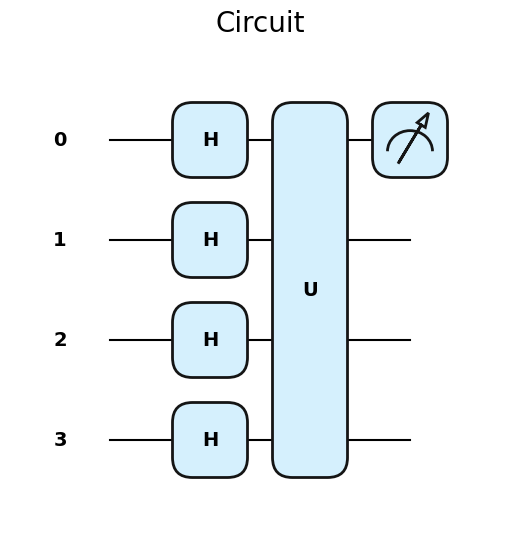

In [39]:
N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

#tem que inicializar o device
qubits=[i for i in range(N_qubits)]
dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit():

    #https://docs.pennylane.ai/en/stable/introduction/operations.html lista dos operadores do pennylane
    #colocar as portas aq
    for i in range(N_qubits):
        qml.Hadamard(wires=[i])
    qml.DiagonalQubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo

state=circuit
print(state)
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()

### Circuito IQC em Qiskit

In [ ]:
# Criando o circuito com um vetor qualquer do dataset para exemplificar

N_atributos=N_FEATURES 
'''
Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
'''
#Escolhendo uma linha aleatória de X para podermos debugar
lista=[i for i in range(len(X_blobs))]
j=int(np.random.choice(lista))

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

# IQC

qc = QuantumCircuit(N_qubits)
qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(range(1,N_qubits))



#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Debugando
print(f'X[{j}]:', X_blobs_new, '; w:', w,'\n')
print('sigmaE')
print(sigmaE)
#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

qubits=[i for i in range(N_qubits)]
# qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
qc.unitary(U,qubits)
qc.draw("mpl")

In [ ]:
#Decompondo em portas U3 e CX
qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
print(dict(qc.count_ops()))
if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
    display(qc.draw('mpl'))

#### Statevector e Matriz Densidade

Aqui vamos avaliar o estado depois da evolução 

##### Statevector

In [ ]:
#Estado completo
sv = Statevector(qc)
'''
'mpl' is not a valid option for drawing Statevector objects. Please choose from:
            'text', 'latex', 'latex_source', 'qsphere', 'hinton',
            'bloch', 'city' or 'paulivec'
'''

display(sv.draw("latex")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("bloch")) #Plota o vetor de estado já em cada espaço de Hilbert
display(sv.draw("qsphere")) #Plota o vetor de estado em uma esfera que mapeia o espaço tensorial originado pelos espaços de Hilbert
display(sv.draw("city")) #Plota o histograma da matriz densidade SEM MEDÍ-LA


##### Partial Trace

Vamos traçar o sis. auxiliar

In [ ]:
rho = partial_trace(sv,qubits[1:])
print(rho)

def blochvector(rho):
    x = np.trace(matriz_pauli_x@rho.data)
    y= np.trace(matriz_pauli_y@rho.data)
    z = np.trace(matriz_pauli_z@rho.data)
    return [x,y,z]
blochvector(rho)


##### Ponto na Casca da superfície da Esfera de Bloch

In [ ]:
b = qutip.Bloch()
b.point_default_color=['k']
b.add_points(blochvector(rho))

b.render()
b.show()

##### Matriz Densidade

In [ ]:
#Ao traçar fora o ambiente

rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
#rho_res = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:]).data

display(rho_res.draw('bloch'))


Como podemos observar, conseguimos marcar o ponto, na superfície da esfera, ao qual o autovetor do SISTEMA pertence. E se fizermos isso durante todo o código?

##### Negatividade

In [ ]:
Negativity = (np.linalg.norm(rho_res)-1)/2

#### Executando o Circuito

In [ ]:
#Executar o circuito
def run_qasm_counts(circ, shots=1024):
  qc.measure_all()
  qasm_simulator = Aer.get_backend("qasm_simulator")
  job = qasm_simulator.run(qc, shots=shots)
  result = job.result()
  return result.get_counts()

counts = run_qasm_counts(qc)
print(counts)
plot_histogram(counts)

## Função que junta tudo até agora

### IQC

In [25]:
def cirq_iqc(data,contador,N_atributos,printar_cirq=False):
    '''
    Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
    '''
    w=np.full(N_atributos,1)
    

    #x=np.random.rand(N_atributos)
    #w=np.random.rand(N_atributos)

    N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)
    qc.h(0) # Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            X_blobs_new.append(0)
            w=np.append(w,0)
        sigmaE=np.diag(X_blobs_new)*w.T
    else:
        sigmaE=np.diag(X_blobs_new)*w.T

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    qubits=[i for i in range(N_qubits)]
    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho)

    def blochvector(rho):
        x = np.trace(matriz_pauli_x@rho.data)
        y = np.trace(matriz_pauli_y@rho.data)
        z = np.trace(matriz_pauli_z@rho.data)
        return [x,y,z]
    
    #Executar o circuito
    def run_qasm_counts(circ, shots=1024):
        qc.measure_all()
        qasm_simulator = Aer.get_backend("qasm_simulator")
        job = qasm_simulator.run(qc, shots=shots)
        result = job.result()
        return result.get_counts()

    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return blochvector(rho)

### IQC:AIL

In [ ]:
X_blobs=preprocessing.normalize(X_blobs,axis=1,norm='l2')
N_qubits=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
qc=QuantumCircuit(N_qubits)
qc.initialize(X_blobs, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
qc.h(0)
qc.h(range(1,N_qubits))

qc.draw('mpl')

In [30]:
def cirq_iqc_ail(data,contador,N_atributos,printar_cirq=False):
    '''
    Numero de atributos do vetor a ser classificado. Adicionamos mais 1 ao numero obtido antes(pois temos o qubit alvo)
    '''
    w=np.full(N_atributos,1)
    

    #x=np.random.rand(N_atributos)
    #w=np.random.rand(N_atributos)

    N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito
    
    X_blobs_new=list(data)
    if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
        for k in range(2**(N_qubits-1) - N_atributos):
            w=np.append(w,0)
            X_blobs_new=np.append(X_blobs_new,0)
        sigmaE=np.diag(w)
    else:
        sigmaE=np.diag(w)
    
    #Podíamos inicializar assim pra facilitar as contas
    '''x=np.random.rand(2**N_atributos)
    w=np.random.rand(2**N_atributos)'''

    # IQC

    qc = QuantumCircuit(N_qubits)

    qc.initialize(data, range(1,N_qubits))# Inicializaçao do estado inicial. Poderia ser qualquer estado.
    qc.h(0)
    qc.h(range(1,N_qubits))



    #Montando os sigmas

    matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
    matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
    matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

    sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

    

    #Operador Unitário
    U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

    qubits=[i for i in range(N_qubits)]
    # qubitstarget = [i for i in range(Ntarget)] - > Desnecessário agora, mas interessante para fazer a generalização
    qc.unitary(U,qubits)
    if contador==0:
        qc.draw("mpl", filename=f'./mpl_complete_U_blobs.png')
    if printar_cirq==True:
        display(qc.draw('mpl')) #display(qc.draw("mpl", filename='./mpl_original.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    #qc.decompose().draw(output="mpl", style="clifford")
    qc = transpile(qc, optimization_level=3, basis_gates=["u3", "cx"])
    if dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50 and contador%N_PRINTINGS==0:
        qc.draw("mpl", filename=f'./mpl_transpiled{contador}_blobs.png')

    if printar_cirq==True and dict(qc.count_ops())['u3']<=50 and dict(qc.count_ops())['u3']<=50:
        print(dict(qc.count_ops()))
        display(qc.draw('mpl')) #display(qc.draw('mpl', filename='./mpl_transpile.pdf')) #Trocar as chamadas se quiser salvar as imagens dos circuitos

    # Mostrando o vetor de estado 
    sv = Statevector(qc)
    if contador%N_PRINTINGS==0:
        sv.draw("city", filename=f'./state_vector_city{contador}_blobs.png')
        sv.draw("bloch", filename=f'./state_vector_bloch{contador}_blobs.png')
        sv.draw("qsphere", filename=f'./state_vector_qsphere{contador}_blobs.png')
    if printar_cirq==True:
        display(sv.draw("latex"))

    rho = partial_trace(DensityMatrix.from_instruction(qc), qubits[1:])
    if printar_cirq==True:
        print(rho)

    def blochvector(rho):
        x = np.trace(matriz_pauli_x@rho.data)
        y= np.trace(matriz_pauli_y@rho.data)
        z = np.trace(matriz_pauli_z@rho.data)
        return [x,y,z]
    
    #Executar o circuito
    def run_qasm_counts(circ, shots=1024):
        qc.measure_all()
        qasm_simulator = Aer.get_backend("qasm_simulator")
        job = qasm_simulator.run(qc, shots=shots)
        result = job.result()
        return result.get_counts()

    counts = run_qasm_counts(qc)
    if contador%N_PRINTINGS==0:
        plot_histogram(counts,filename=f'./histogram_plot_{contador}_blobs.png')
    


    return blochvector(rho)

## Esfera de Bloch do Circuito

### IQC

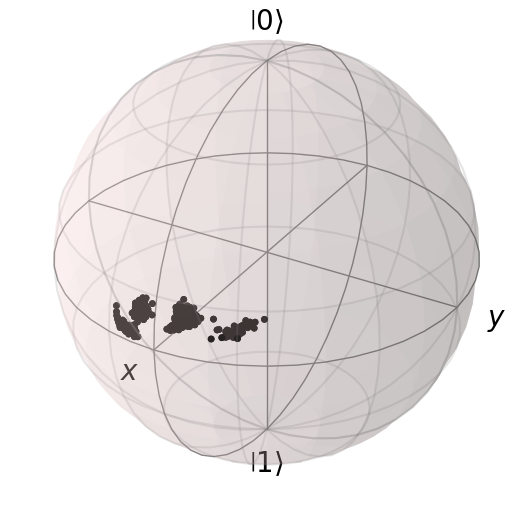

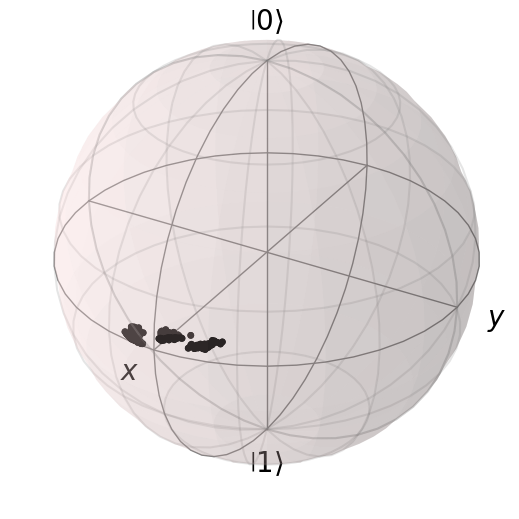

In [26]:
def normalize_iqc(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler((-1,0)) #Normalize the column between [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [0,1]
    return data
    
X_blobs_iqc_coluna=normalize_iqc(X_blobs, normalize_col=True, normalize_lin=False)
X_blobs_iqc_linha=normalize_iqc(X_blobs, normalize_col=False, normalize_lin=True)

def esfera_bloch_IQC(X,counter,norma):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc(X[k],k,N_FEATURES))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_blobs{counter}_IQC_AIL_{norma}.png')

esfera_bloch_IQC(X_blobs_iqc_coluna,1,'coluna')
esfera_bloch_IQC(X_blobs_iqc_linha,1,'linha')

### IQC:AIL

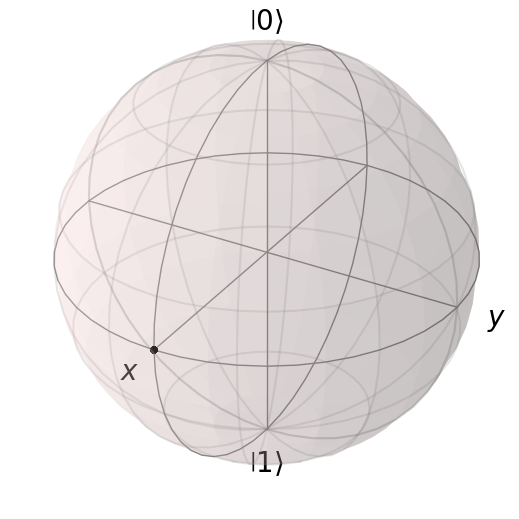

In [31]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        scaler = MinMaxScaler() #Normalize the column between [0,1]
        scaler.fit(data)
        data = scaler.transform(data)
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normalize the line between [0,1]
    return data
    
X_blobs_iqc_ail_coluna=normalize_iqc_ail(X_blobs, normalize_col=True, normalize_lin=False) 
'''
Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
normalizar as linhas entre si

'''
X_blobs_iqc_ail_coluna=preprocessing.normalize(X_blobs_iqc_ail_coluna,axis=1,norm='l2')
X_blobs_iqc_ail_linha=normalize_iqc_ail(X_blobs,normalize_col=False,normalize_lin=True)

def esfera_bloch_IQC_AIL(X,counter,norma):
    point_states=[]
    for k in range(0,N_SAMPLES):
        point_states.append(cirq_iqc_ail(X[k],k,N_FEATURES))

    b = qutip.Bloch()
    b.point_default_color=['k']
    b.point_marker=['o']
    b.point_size=[15, 15, 15, 15]
    for k in range(len(point_states)):
        b.add_points(point_states[k])
    b.render()
    b.show()

    bb = b.fig
    bb.savefig(f'Bloch_geral_blobs{counter}_IQC_AIL_{norma}.png')

#esfera_bloch_IQC_AIL(X_blobs_iqc_ail_coluna,1,'coluna')
esfera_bloch_IQC_AIL(X_blobs_iqc_ail_linha,1,'linha')

In [ ]:
N_qubits=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
for i in range(1,N_qubits):
    print(i)

In [ ]:
for i in range(N_SAMPLES):
    print(np.linalg.norm(X_blobs_iqc_ail_coluna[i]))
    print(np.linalg.norm(X_blobs_iqc_ail_linha[i]),'\n')

## Amplitude Embedding Pennylane

In [52]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

w=np.full(N_atributos,1)

#x=np.random.rand(N_atributos)
#w=np.random.rand(N_atributos)

N_qubits=math.ceil(np.log2(N_atributos)+1) #Nqubits do circuito

#Podíamos inicializar assim pra facilitar as contas
'''x=np.random.rand(2**N_atributos)
w=np.random.rand(2**N_atributos)'''

#Montando os sigmas

matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z

sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z



X_blobs_new=list(X_blobs[j])
if np.log2(N_atributos)%2!=0 and np.log2(N_atributos)!=1:
    for k in range(2**(N_qubits-1) - N_atributos):
        X_blobs_new.append(0)
        w=np.append(w,0)
    sigmaE=np.diag(X_blobs_new)*w.T
else:
    sigmaE=np.diag(X_blobs_new)*w.T

#Operador Unitário
U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=range(1,N_qubits), pad_with=True)
    qml.DiagonalQubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo
rho=circuit(np.ones(N_qubits-1))
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl()()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()


ValueError: Operator must be unitary.

## Angle Embedding Pennylane

In [ ]:
from qiskit import QuantumCircuit
from qiskit.circuit import Parameter

'''custom_circ = QuantumCircuit(N_qubits)
theta = Parameter("\u03B8")
custom_circ.h(0)
custom_circ.rz(theta, range(1,N_qubits))
custom_circ.draw('mpl')'''

#my_qc=qml.from_qiskit(custom_circ, measurements=None)

dev = qml.device("default.qubit", wires = qubits)

@qml.qnode(dev)
def circuit(f=None):
    qml.AmplitudeEmbedding(features=f,wires=(1,N_qubits))
    qml.DiagonalQubitUnitary(U, wires=qubits)

    return qml.density_matrix([0]) #Retorna a matriz reduzida do qubit alvo
qml.drawer.use_style('pennylane')
fig, ax = qml.draw_mpl(circuit)()
ax.set_aspect('equal')
fig.set_figwidth(20)
plt.title("Circuit",size = 20)
plt.show()


## IQC

In [3]:
def IQC(x,w):
  n = len(x)

  #from sympy.physics.matrices import msigma(indice)

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE

## IQC:AIL

In [ ]:
def IQC_AIL(x,w):
  n = len(x)
  norma_x=np.linalg.norm(x)+1e-16 #To avoid zero division

  #Matrizes de Pauli e a matriz sigma-Q
  matriz_pauli_x=np.array([[0,1],[1,0]]) # Matriz de Pauli x
  matriz_pauli_y=np.array([[0,-1j],[1j,0]]) # Matriz de Pauli y
  matriz_pauli_z=np.array([[1,0],[0,-1]]) # Matriz de Pauli z



  sigmaQ=matriz_pauli_x+matriz_pauli_y+matriz_pauli_z

  sigmaE=np.diag(x)*w.T #No fim, é uma matriz composta apenas por pesos

  #Operador Unitário
  #Hint=- hbar*g*np.kron(sigmaQ,sigmaE)
  #U=expMatrix(-1j*Hint*(t/hbar))
  U=np.matrix(expMatrix(1j*np.kron(sigmaQ,sigmaE)))

  def get_p(psi):
    psi=np.matrix(psi)
    return psi*psi.getH()

  #Psis
  #Para os qubits
  psiQ=np.ones((2,1))
  psiQ=(psiQ/np.sqrt(2))

  psiE=np.ones((n,1))
  psiE=(psiE/np.sqrt(n))


  #Rhos
  rhoQ=get_p(psiQ)
  rhoE=get_p(psiE)
  rho_2_systems = np.array(U*(np.kron(rhoQ,rhoE))*Dagger(U))
  #p_cog_new = partial_trace(rho_2_systems, sys=2,dim=[2,n])
  rho_cog_new  = np.trace(rho_2_systems.reshape([2,n,2,n]), axis1=1, axis2=3)
  return rho_cog_new,sigmaE